# Case Study: Teacher Effectiveness Ratings (CLMM)

This notebook demonstrates **cumulative link mixed models (CLMM)** using `interlace.clmm()` — the Python equivalent of R's `ordinal::clmm()`. CLMMs are the right tool when your outcome is an **ordered categorical variable** (Likert scale, pain ratings, quality grades) and observations are clustered.

## Scenario

We analyse synthetic **teacher effectiveness ratings** collected from students. The design:

| Feature | Value |
|---|---|
| Teachers | 20 |
| Students per teacher | 10 |
| Total observations | 200 |
| Outcome | 5-point rating (1 = poor … 5 = excellent) |
| Fixed effects | `method` (traditional / active), `size` (large / small) |
| Random effect | Teacher intercept |
| Design | Balanced 2×2, 5 teachers per cell |

Both predictors vary **at the teacher level** (not within teacher), so the teacher random effect absorbs unmeasured instructor-level heterogeneity.

In [1]:
import numpy as np
import pandas as pd
import interlace
from scipy.special import expit
from plotnine import (
    ggplot, aes, geom_bar, geom_point, geom_errorbar, geom_line,
    facet_grid, facet_wrap, coord_flip, labs, theme_bw, theme,
    scale_fill_manual, scale_color_manual, scale_linetype_manual,
    element_text, element_blank, geom_hline, scale_y_continuous,
)

# True parameters
TRUE_THRESHOLDS = np.array([-2.0, -0.5, 0.8, 2.1])
TRUE_BETA_METHOD = 1.2   # active → higher ratings
TRUE_BETA_SIZE = -0.3    # small → slightly higher ratings
TRUE_SD_TEACHER = 0.8

rng = np.random.default_rng(42)

conditions = (
    [('traditional', 'large')] * 5 + [('traditional', 'small')] * 5 +
    [('active', 'large')] * 5 + [('active', 'small')] * 5
)
u_teacher = rng.normal(0, TRUE_SD_TEACHER, 20)

rows = []
for j in range(20):
    method, size = conditions[j]
    eta = (TRUE_BETA_METHOD * (method == 'active')
           + TRUE_BETA_SIZE * (size == 'small')
           + u_teacher[j])
    cum_probs = expit(TRUE_THRESHOLDS - eta)
    cat_probs = np.diff(np.concatenate([[0], cum_probs, [1]]))
    cat_probs = np.clip(cat_probs, 1e-10, None)
    cat_probs /= cat_probs.sum()
    ratings = rng.choice(np.arange(1, 6), size=10, p=cat_probs)
    for r in ratings:
        rows.append({'teacher': f'T{j+1:02d}', 'method': method,
                     'size': size, 'rating': int(r)})

df = pd.DataFrame(rows)
print(f"Shape: {df.shape}")
print("\nRating distribution:")
print(df['rating'].value_counts().sort_index())

Shape: (200, 4)

Rating distribution:
rating
1    23
2    52
3    43
4    42
5    40
Name: count, dtype: int64


In [2]:
df.head(8)

,teacher,method,size,rating
0,T01,traditional,large,4
1,T01,traditional,large,3
2,T01,traditional,large,5
3,T01,traditional,large,5
4,T01,traditional,large,4
5,T01,traditional,large,2
6,T01,traditional,large,3
7,T01,traditional,large,1


## Exploratory Data Analysis

We expect active-method teachers to receive higher ratings, and small-class teachers to receive slightly higher ratings. The stacked proportional bar chart shows the rating distribution for each condition.

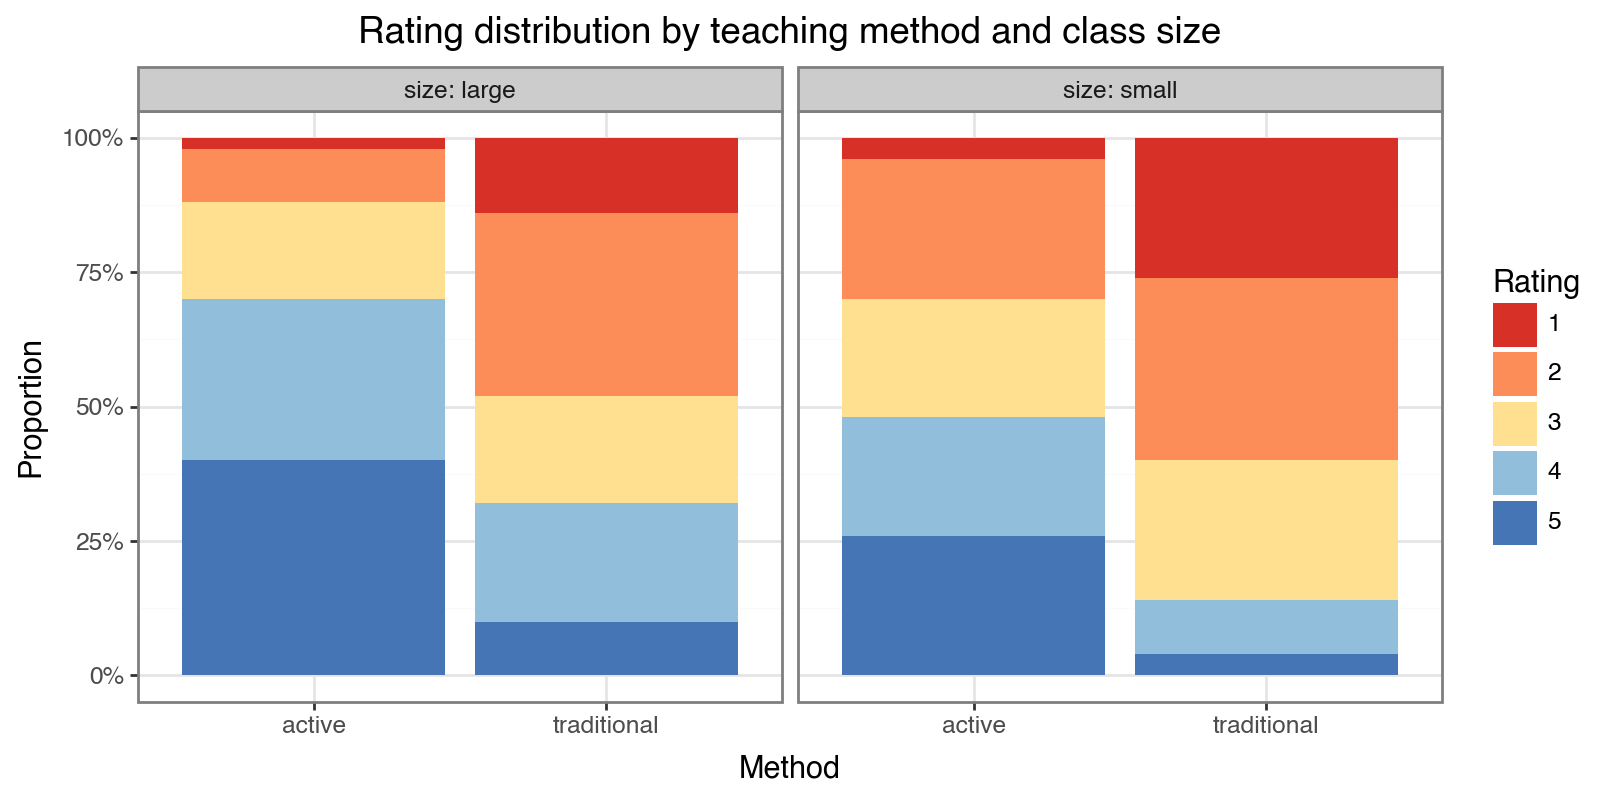

In [3]:
ORDINAL_PALETTE = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']

(
    ggplot(df, aes(x='method', fill='factor(rating)'))
    + geom_bar(position='fill')
    + facet_wrap('size', labeller='label_both')
    + scale_fill_manual(values=ORDINAL_PALETTE, name='Rating')
    + scale_y_continuous(labels=lambda l: [f"{v:.0%}" for v in l])
    + labs(
        title='Rating distribution by teaching method and class size',
        x='Method', y='Proportion',
    )
    + theme_bw()
    + theme(figure_size=(8, 4))
)

## Model Specification

The cumulative link mixed model (proportional-odds formulation) is:

$$
\operatorname{logit}[P(Y_{ij} \leq k)] = \alpha_k - (\beta_1 \cdot \text{method}_j + \beta_2 \cdot \text{size}_j + u_j)
$$

where $\alpha_1 < \alpha_2 < \alpha_3 < \alpha_4$ are the **threshold** parameters and $u_j \sim \mathcal{N}(0, \sigma^2)$ is the teacher random intercept.

The `interlace.clmm()` call mirrors `statsmodels.MixedLM.from_formula()`: a Wilkinson–Rogers formula for fixed effects, plus `groups=` for the clustering variable.

In [4]:
result = interlace.clmm(
    formula="rating ~ method + size",
    data=df,
    groups="teacher",
    link="logit",
)

print(f"Converged : {result.converged}")
print(f"N obs     : {result.nobs}")
print(f"AIC       : {result.aic:.2f}")
print(f"BIC       : {result.bic:.2f}")

Converged : True
N obs     : 200
AIC       : 595.22
BIC       : 618.30


In [5]:
thr = result.thresholds
thr_keys = list(thr.keys())
thr_values = np.array(list(thr.values()))
thr_df = pd.DataFrame({
    'threshold': thr_keys,
    'estimate': thr_values,
    'true': TRUE_THRESHOLDS,
    'abs_error': np.abs(thr_values - TRUE_THRESHOLDS),
})
print("Thresholds (logit scale — more negative = lower cumulative probability):")
thr_df.round(3)

Thresholds (logit scale — more negative = lower cumulative probability):


,threshold,estimate,true,abs_error
0,1|2,-3.730,-2.0,1.730
1,2|3,-1.927,-0.5,1.427
2,3|4,-0.829,0.8,1.629
3,4|5,0.409,2.1,1.691


In [6]:
ci = result.confint()          # DataFrame indexed by param name
# Keep only fixed-effect rows (exclude threshold rows)
fe_names = list(result.fe_params.index)
fe_ci = ci.loc[fe_names]

fe_table = pd.DataFrame({
    'estimate': result.fe_params,
    'SE':       result.fe_bse[fe_names],
    'OR':       np.exp(result.fe_params),
    'CI_lower': np.exp(fe_ci.iloc[:, 0]),
    'CI_upper': np.exp(fe_ci.iloc[:, 1]),
}, index=fe_names)

print("Fixed effects (OR = odds ratio for moving to a higher rating category):")
fe_table.round(3)

Fixed effects (OR = odds ratio for moving to a higher rating category):


,estimate,SE,OR,CI_lower,CI_upper
method[T.traditional],-1.735,0.351,0.176,0.089,0.351
size[T.small],-0.830,0.338,0.436,0.225,0.846


In [7]:
pred_grid = pd.DataFrame({
    'method':  ['traditional', 'traditional', 'active', 'active'],
    'size':    ['large',       'small',       'large',  'small'],
    'teacher': ['T_new'] * 4,
})

probs = result.predict(newdata=pred_grid, type="prob")

prob_df = pred_grid[['method', 'size']].copy()
for k in range(1, 6):
    prob_df[f'P({k})'] = probs[:, k - 1].round(3)

print("Predicted category probabilities for an average new teacher (u=0):")
prob_df

Predicted category probabilities for an average new teacher (u=0):


,method,size,P(1),P(2),P(3),P(4),P(5)
0,traditional,large,0.120,0.332,0.260,0.183,0.105
1,traditional,small,0.238,0.417,0.196,0.101,0.049
2,active,large,0.023,0.104,0.177,0.297,0.399
3,active,small,0.052,0.198,0.250,0.275,0.225


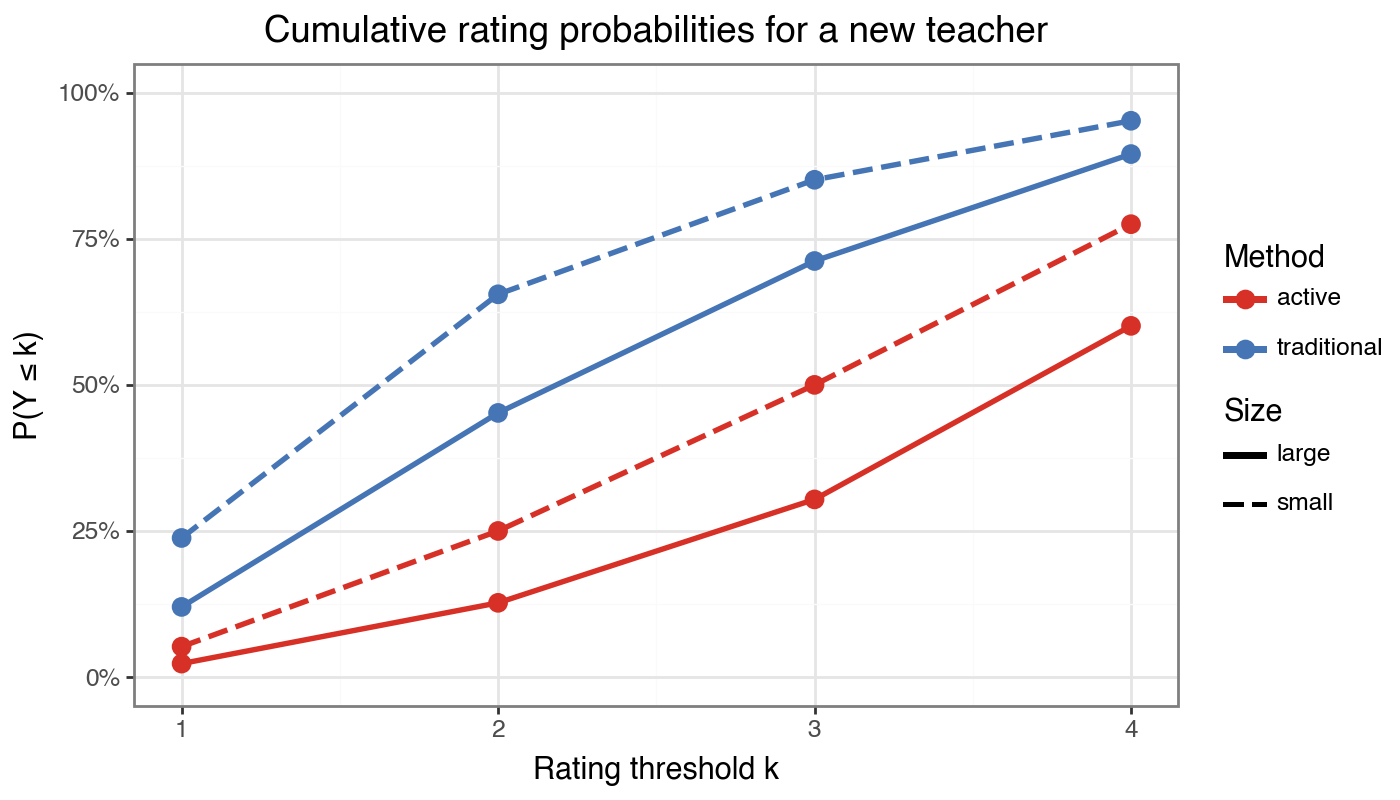

In [8]:
# Build cumulative probability curves P(Y <= k) for k=1..4
cum_rows = []
for _, row in prob_df.iterrows():
    cond = f"{row['method']}/{row['size']}"
    cump = 0.0
    for k in range(1, 5):
        cump += row[f'P({k})']
        cum_rows.append({'condition': cond, 'k': k, 'cum_prob': cump,
                         'method': row['method'], 'size': row['size']})

cum_df = pd.DataFrame(cum_rows)

(
    ggplot(cum_df, aes(x='k', y='cum_prob',
                       color='method', linetype='size', group='condition'))
    + geom_line(size=1.1)
    + geom_point(size=3)
    + scale_color_manual(values=['#d73027', '#4575b4'], name='Method')
    + scale_linetype_manual(values=['solid', 'dashed'], name='Size')
    + scale_y_continuous(limits=[0, 1],
                         labels=lambda l: [f"{v:.0%}" for v in l])
    + labs(
        title='Cumulative rating probabilities for a new teacher',
        x='Rating threshold k', y='P(Y \u2264 k)',
    )
    + theme_bw()
    + theme(figure_size=(7, 4))
)

In [9]:
# Teacher BLUPs with ±1.96 * teacher SD uncertainty bands
blups_series = result.random_effects['teacher']
teacher_sd = float(result.variance_components['teacher']) ** 0.5
half_width = 1.96 * teacher_sd

blup_df = pd.DataFrame({
    'teacher': blups_series.index,
    'blup': blups_series.values,
}).sort_values('blup').reset_index(drop=True)

# Attach method info for colouring
teacher_meta = df.drop_duplicates('teacher')[['teacher', 'method']]
blup_df = blup_df.merge(teacher_meta, on='teacher')
blup_df['teacher'] = pd.Categorical(blup_df['teacher'],
                                     categories=blup_df['teacher'].tolist(),
                                     ordered=True)

(
    ggplot(blup_df, aes(x='teacher', y='blup', color='method'))
    + geom_hline(yintercept=0, linetype='dashed', color='grey60')
    + geom_errorbar(
        aes(ymin='blup - ' + str(half_width),
            ymax='blup + ' + str(half_width)),
        width=0.4,
    )
    + geom_point(size=3)
    + coord_flip()
    + scale_color_manual(values=['#d73027', '#4575b4'], name='Method')
    + labs(
        title='Teacher BLUPs (sorted) with \u00b11.96\u00d7SD bands',
        x='Teacher', y='Random intercept (logit scale)',
    )
    + theme_bw()
    + theme(figure_size=(6, 7),
            axis_text_y=element_text(size=8))
)

ValueError: Unknown name 'grey60' for a color.

In [10]:
result_probit = interlace.clmm(
    formula="rating ~ method + size",
    data=df,
    groups="teacher",
    link="probit",
)

compare = pd.DataFrame({
    'logit_est':  result.fe_params.round(3).values,
    'logit_SE':   result.fe_bse[fe_names].round(3).values,
    'probit_est': result_probit.fe_params.round(3).values,
    'probit_SE':  result_probit.fe_bse[fe_names].round(3).values,
}, index=fe_names)

print("Logit vs probit link — fixed effects:")
print(compare.to_string())
print(f"\nLogit  AIC: {result.aic:.2f}  |  Probit AIC: {result_probit.aic:.2f}")
print("(Estimates on probit scale are ~0.59× logit — the π/√3 rescaling)")

Logit vs probit link — fixed effects:
                       logit_est  logit_SE  probit_est  probit_SE
method[T.traditional]     -1.735     0.351      -1.033      0.198
size[T.small]             -0.830     0.338      -0.480      0.193

Logit  AIC: 595.22  |  Probit AIC: 594.35
(Estimates on probit scale are ~0.59× logit — the π/√3 rescaling)


## Summary

**Workflow checklist for CLMMs with `interlace`:**

- [ ] Confirm the outcome is genuinely ordered (not nominal).
- [ ] Identify the clustering variable and check group sizes.
- [ ] Call `interlace.clmm(formula, data, groups, link="logit")` and verify `result.converged`.
- [ ] Inspect thresholds for ordering ($\alpha_1 < \alpha_2 < \ldots$).
- [ ] Interpret fixed-effect odds ratios (logit link) or cumulative probability shifts.
- [ ] Use `result.predict(newdata, type="prob")` for marginal predictions at new group levels.
- [ ] Check the BLUP caterpillar plot — wide spread indicates substantial teacher heterogeneity.
- [ ] Compare logit vs probit AIC to confirm link choice.

**Where to go next:**

- {doc}`clmm-quickstart` — minimal working example and API reference
- {doc}`api/clmm` — full parameter and return-value documentation
- {doc}`case-study-glmm` — count outcomes (Poisson/NB) with crossed random effects